In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

In [ ]:
admissions_data = pd.read_csv('admissions.csv')
fatalities_data = pd.read_csv('fatalities.csv')
metrics_data = pd.read_csv('metrics.csv')
prescriptions_data = pd.read_csv('prescriptions.csv')
smokers_data = pd.read_csv('smokers.csv')

In [ ]:
print(admissions_data.head(5))
print(fatalities_data.head(5))
print(metrics_data.head(5))
print(prescriptions_data.head(5))
print(smokers_data.head(5))

      Year                                         ICD10 Code  \
0  2014/15                                          All codes   
1  2014/15  C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...   
2  2014/15                                            C00-D48   
3  2014/15                                            J00-J99   
4  2014/15                                            I00-I99   

                               ICD10 Diagnosis  \
0                               All admissions   
1  All diseases which can be caused by smoking   
2                                  All cancers   
3                     All respiratory diseases   
4                     All circulatory diseases   

                                Diagnosis Type                Metric  Sex  \
0                               All admissions  Number of admissions  NaN   
1  All diseases which can be caused by smoking  Number of admissions  NaN   
2                                  All cancers  Number of admissions  NaN   


In [ ]:
print(admissions_data.tail(5))
print(fatalities_data.tail(5))
print(metrics_data.tail(5))
print(prescriptions_data.tail(5))
print(smokers_data.tail(5))

         Year   ICD10 Code                     ICD10 Diagnosis  \
2074  2004/05          K50                      Crohns Disease   
2075  2004/05          K05  Periodontal Disease / Periodonitis   
2076  2004/05          H25            Age Related Cataract 45+   
2077  2004/05  S72.0-S72.2                    Hip Fracture 55+   
2078  2004/05          O03                Spontaneous Abortion   

                                         Diagnosis Type               Metric  \
2074  Digestive diseases which can be caused caused ...  Attributable number   
2075  Digestive diseases which can be caused caused ...  Attributable number   
2076      Other diseases which can be caused by smoking  Attributable number   
2077      Other diseases which can be caused by smoking  Attributable number   
2078      Other diseases which can be caused by smoking  Attributable number   

         Sex Value  
2074  Female  1400  
2075  Female   700  
2076  Female  8900  
2077  Female  4900  
2078  Female   70

In [ ]:
print(admissions_data.columns)
print(fatalities_data.columns)
print(metrics_data.columns)
print(prescriptions_data.columns)
print(smokers_data.columns)

Index(['Year', 'ICD10 Code', 'ICD10 Diagnosis', 'Diagnosis Type', 'Metric',
       'Sex', 'Value'],
      dtype='object')
Index(['Year', 'ICD10 Code', 'ICD10 Diagnosis', 'Diagnosis Type', 'Metric',
       'Sex', 'Value'],
      dtype='object')
Index(['Year', 'Tobacco Price\nIndex', 'Retail Prices\nIndex',
       'Tobacco Price Index Relative to Retail Price Index',
       'Real Households' Disposable Income', 'Affordability of Tobacco Index',
       'Household Expenditure on Tobacco', 'Household Expenditure Total',
       'Expenditure on Tobacco as a Percentage of Expenditure'],
      dtype='object')
Index(['Year', 'All Pharmacotherapy Prescriptions',
       'Nicotine Replacement Therapy (NRT) Prescriptions',
       'Bupropion (Zyban) Prescriptions',
       'Varenicline (Champix) Prescriptions',
       'Net Ingredient Cost of All Pharmacotherapies',
       'Net Ingredient Cost of Nicotine Replacement Therapies (NRT)',
       'Net Ingredient Cost of Bupropion (Zyban)',
       'Net Ingre

In [ ]:
df = pd.concat([fatalities_data, smokers_data,admissions_data,metrics_data,prescriptions_data],axis =1)
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 41 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Year                                                         1749 non-null   float64
 1   ICD10 Code                                                   1749 non-null   object 
 2   ICD10 Diagnosis                                              1749 non-null   object 
 3   Diagnosis Type                                               1749 non-null   object 
 4   Metric                                                       1749 non-null   object 
 5   Sex                                                          1166 non-null   object 
 6   Value                                                        1749 non-null   object 
 7   Year                                                         84 non-null     f

In [ ]:
df.isna().sum()

Year                                                            330
ICD10 Code                                                      330
ICD10 Diagnosis                                                 330
Diagnosis Type                                                  330
Metric                                                          330
Sex                                                             913
Value                                                           330
Year                                                           1995
Method                                                         1995
Sex                                                            2023
16 and Over                                                    1995
16-24                                                          1995
25-34                                                          1995
35-49                                                          1995
50-59                                           

In [ ]:
df.shape


(2079, 41)

In [ ]:
df.dropna()

,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value,Year,Method,Sex,...,Expenditure on Tobacco as a Percentage of Expenditure,Year,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix)


In [ ]:
print (f"Amount of duplicates:{df.duplicated().sum()}")

Amount of duplicates:0


In [ ]:
df.describe()

,Year,Year,16 and Over,16-24,25-34,35-49,50-59,60 and Over,Year,Tobacco Price\nIndex,...,Household Expenditure Total,Expenditure on Tobacco as a Percentage of Expenditure,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix)
count,1749.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,36.000000,36.000000,...,3.100000e+01,31.000000,11.000000,11.000000,11.000000,9.000000,11.000000,11.000000,11.000000,9.000000
mean,2009.000000,1997.250000,27.892857,31.345238,33.678571,31.285714,28.952381,18.750000,1997.500000,520.744444,...,6.520081e+05,2.241935,2179.454545,1541.636364,66.454545,698.444444,54263.090909,32221.636364,2512.818182,23868.444444
std,3.163182,12.142601,7.525087,5.954636,7.287819,8.161873,9.376855,7.441134,10.535654,336.517379,...,2.859747e+05,0.447045,366.163724,388.608099,46.409834,294.100370,9415.126292,7457.243771,1654.570870,9942.113383
min,2004.000000,1974.000000,17.000000,20.000000,20.000000,20.000000,18.000000,10.000000,1980.000000,100.000000,...,2.144490e+05,1.700000,1348.000000,766.000000,21.000000,22.000000,38145.000000,18208.000000,807.000000,760.000000
25%,2006.000000,1987.500000,22.000000,26.000000,28.000000,25.000000,22.000000,13.000000,1988.750000,219.550000,...,4.085960e+05,1.800000,2061.500000,1405.000000,28.000000,612.000000,47092.500000,29376.000000,1105.000000,21714.000000
50%,2009.000000,2000.500000,27.000000,33.000000,34.000000,29.500000,26.000000,16.000000,1997.500000,445.700000,...,6.394050e+05,2.200000,2205.000000,1545.000000,47.000000,714.000000,57520.000000,30951.000000,2060.000000,24694.000000
75%,2012.000000,2007.250000,32.000000,35.000000,37.000000,36.000000,34.250000,23.000000,2006.250000,723.150000,...,9.050715e+05,2.500000,2479.000000,1832.000000,113.000000,877.000000,62452.000000,37813.000000,4098.500000,29936.000000
max,2014.000000,2014.000000,51.000000,47.000000,55.000000,55.000000,53.000000,44.000000,2015.000000,1294.300000,...,1.152387e+06,3.300000,2564.000000,2076.000000,136.000000,987.000000,65883.000000,43465.000000,5151.000000,33494.000000


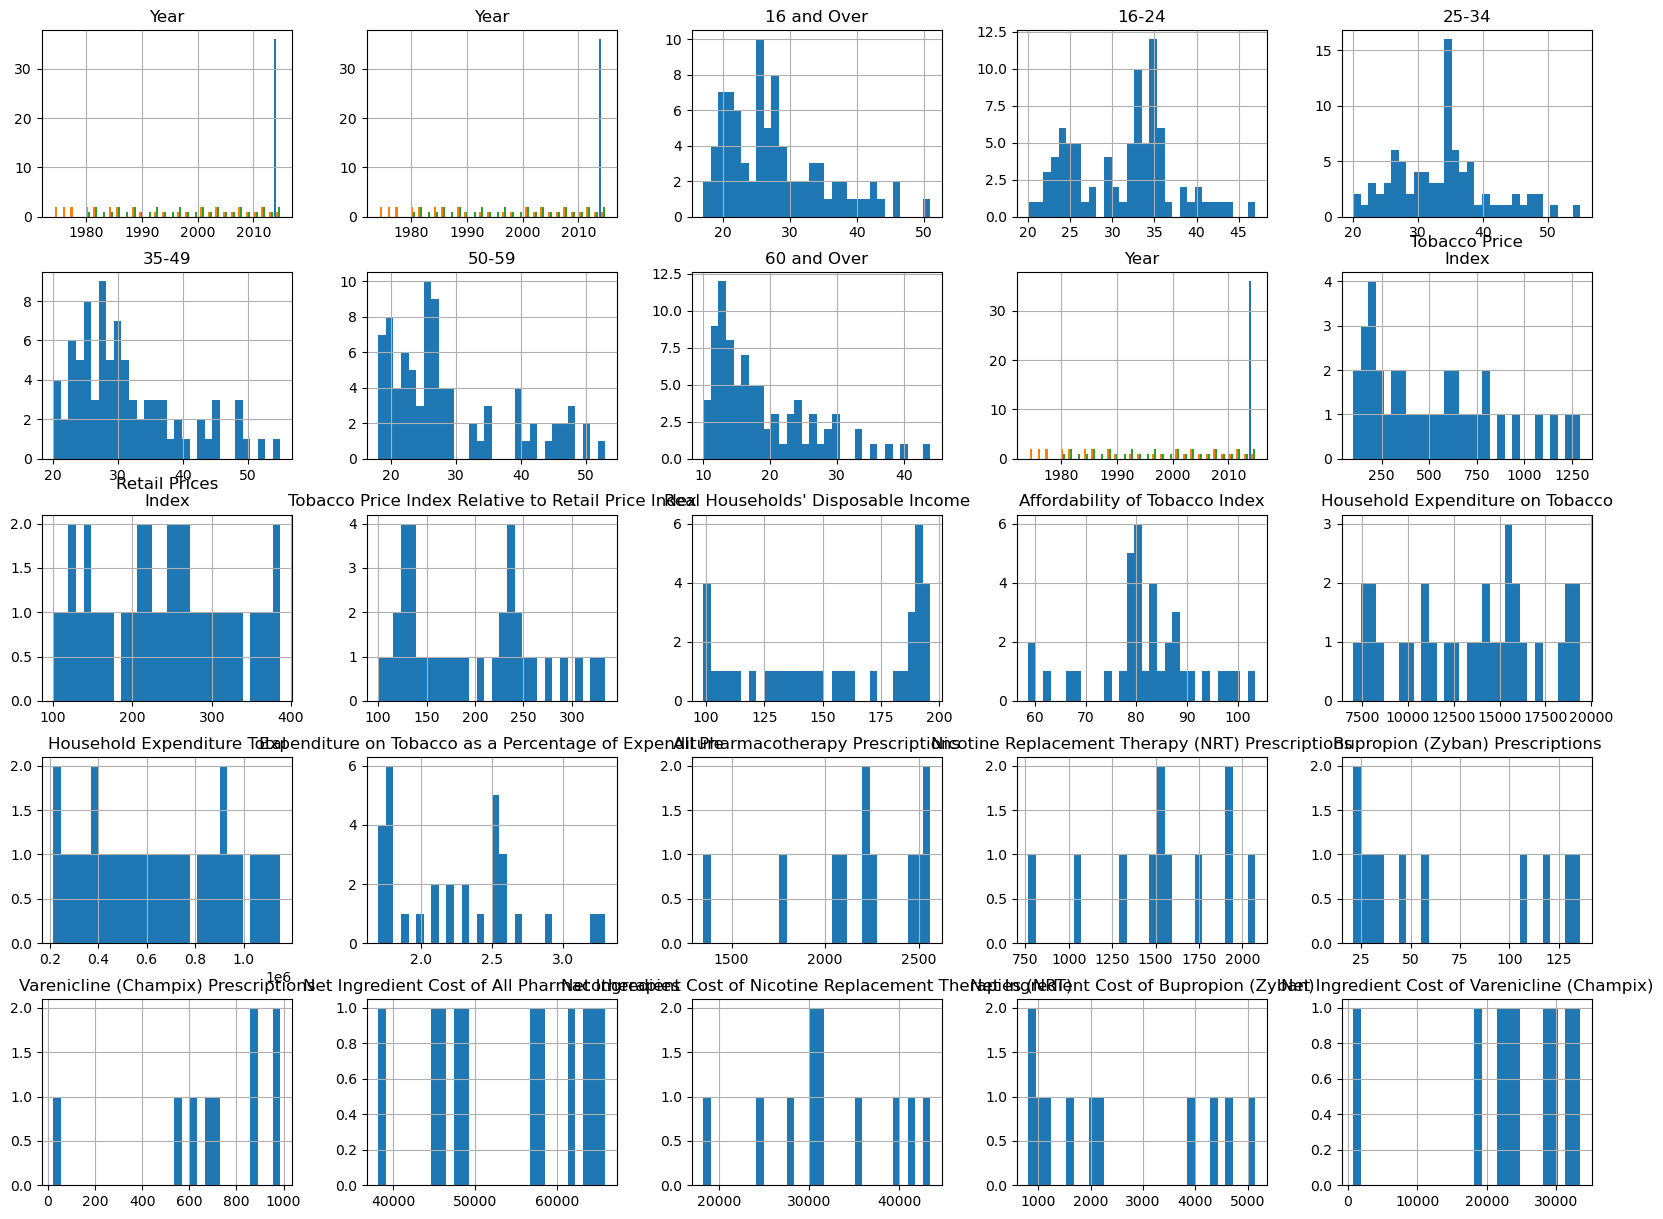

In [ ]:
df.hist(bins = 30, figsize = (20,15))
plt.show()

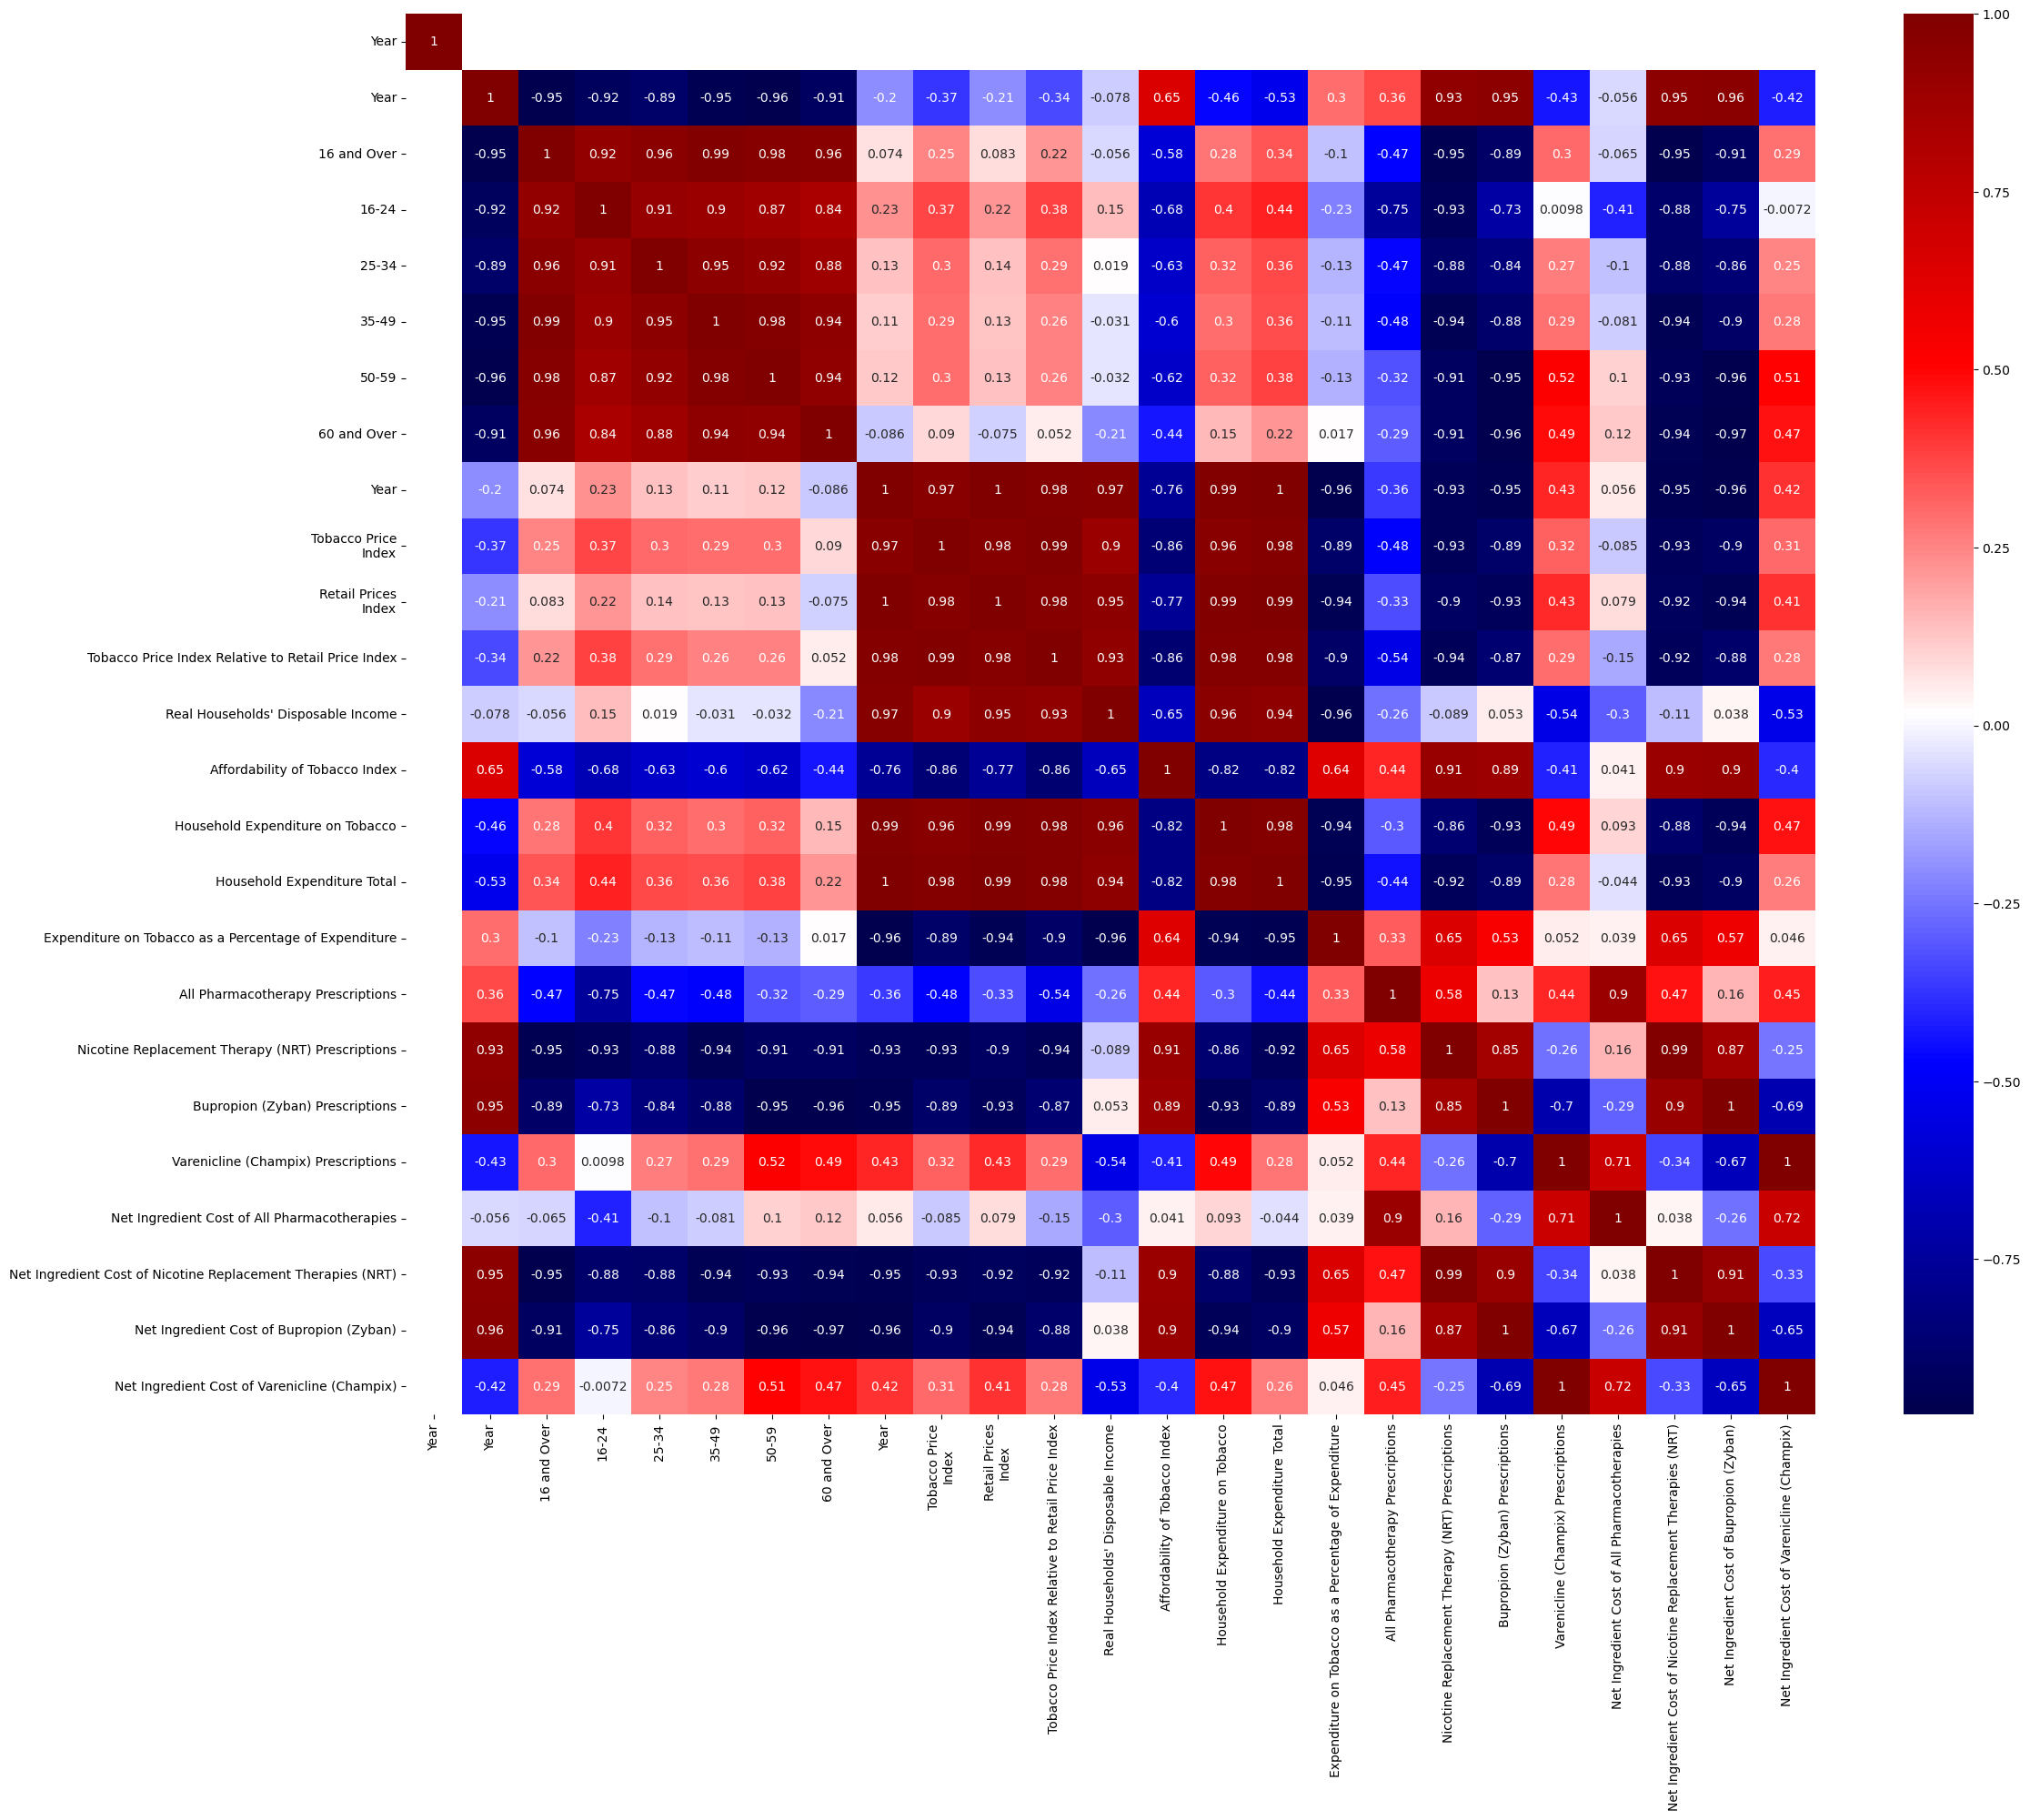

In [ ]:
numeric_df = df.select_dtypes(include = ['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize = (25,20))
sns.heatmap(corr_matrix,annot = True,cmap = 'seismic')
plt.show()